In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn

from sklearn.metrics import r2_score

In [42]:
#LOAD DATA
COLS = ['unit', 'cycle',
        'op_set_1', 'op_set_2', 'op_set_3',
        's1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
        's11','s12','s13','s14','s15','s16','s17','s18','s19',
        's20','s21']

train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=COLS)
test_df  = pd.read_csv('test_FD001.txt',  sep=r'\s+', header=None, names=COLS)
rul_df   = pd.read_csv('RUL_FD001.txt',   sep=r'\s+', header=None, names=['RUL'])

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)
rul_df.to_csv("rul.csv", index=False)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
#check if any null values in dataset
print(train_df.isnull().values.any())
print(test_df.isnull().values.any())
print(rul_df.isnull().values.any())

Train: (20631, 26)
Test: (13096, 26)
False
False
False


In [43]:
#FEATURE SELECTION
DROP_SENSORS = ['s1','s5','s6','s10','s16','s18','s19']
DROP_OPS     = ['op_set_3']

FEATURE_COLS = [c for c in COLS[2:]
                if c not in DROP_SENSORS + DROP_OPS]



In [44]:
#ADD RUL
MAX_RUL = 125

def add_rul(df):
    max_cycle = df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']
    df = df.merge(max_cycle, on='unit')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df['RUL'] = df['RUL'].clip(upper=MAX_RUL)
    df.drop(columns='max_cycle', inplace=True)
    return df

train_df = add_rul(train_df)
train_df['RUL'] = train_df['RUL'] / MAX_RUL



In [45]:
#NORMALIZE
scaler = MinMaxScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])



In [46]:
#SEQUENCE GENERATION
SEQ_LEN = 30

def make_sequences(df, seq_len, feature_cols, label_col=None):
    X, y = [], []
    for _, group in df.groupby('unit'):
        data = group[feature_cols].values
        labels = group[label_col].values if label_col else None
        
        for i in range(len(data) - seq_len + 1):
            X.append(data[i:i+seq_len])
            if label_col:
                y.append(labels[i+seq_len-1])
    
    return np.array(X), np.array(y) if label_col else np.array(X)

X_train, y_train = make_sequences(train_df, SEQ_LEN, FEATURE_COLS, 'RUL')

def make_test_sequences(df, seq_len, feature_cols):
    X = []
    for _, group in df.groupby('unit'):
        data = group[feature_cols].values
        if len(data) >= seq_len:
            X.append(data[-seq_len:])
        else:
            pad = np.zeros((seq_len - len(data), len(feature_cols)))
            X.append(np.vstack([pad, data]))
    return np.array(X)

X_test = make_test_sequences(test_df, SEQ_LEN, FEATURE_COLS)
y_test = np.clip(rul_df['RUL'].values, 0, MAX_RUL) 
y_test = y_test / MAX_RUL

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)



Train: (17731, 30, 16) (17731,)
Test: (100, 30, 16) (100,)


In [47]:
#MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, 64, batch_first=True)
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        self.fc1 = nn.Linear(32, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = LSTMModel(X_train.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)



In [48]:
#TRAINING
EPOCHS = 30
BATCH = 256

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(X_train_t.size(0))
    loss_total = 0

    for i in range(0, X_train_t.size(0), BATCH):
        idx = perm[i:i+BATCH]
        xb = X_train_t[idx]
        yb = y_train_t[idx]

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"Epoch {epoch+1}: Loss = {loss_total:.4f}")



Epoch 1: Loss = 12.2594
Epoch 2: Loss = 2.6032
Epoch 3: Loss = 1.6892
Epoch 4: Loss = 1.2314
Epoch 5: Loss = 1.0430
Epoch 6: Loss = 0.9943
Epoch 7: Loss = 0.9529
Epoch 8: Loss = 0.9614
Epoch 9: Loss = 0.8899
Epoch 10: Loss = 0.8708
Epoch 11: Loss = 0.8953
Epoch 12: Loss = 0.8800
Epoch 13: Loss = 0.8798
Epoch 14: Loss = 0.8309
Epoch 15: Loss = 0.8147
Epoch 16: Loss = 0.8192
Epoch 17: Loss = 0.8138
Epoch 18: Loss = 0.8204
Epoch 19: Loss = 0.8149
Epoch 20: Loss = 0.7918
Epoch 21: Loss = 0.7811
Epoch 22: Loss = 0.8169
Epoch 23: Loss = 0.8034
Epoch 24: Loss = 0.7657
Epoch 25: Loss = 0.7642
Epoch 26: Loss = 0.7781
Epoch 27: Loss = 0.7428
Epoch 28: Loss = 0.7557
Epoch 29: Loss = 0.7466
Epoch 30: Loss = 0.7572


In [49]:
#EVALUATION
model.eval()
with torch.no_grad():
    preds = model(X_test_t).cpu().numpy().flatten()

# Convert back to real RUL
preds = preds * MAX_RUL
y_test = y_test * MAX_RUL


preds = np.clip(preds, 0, MAX_RUL)


===== FINAL RESULTS =====
RMSE: 13.00
MAE : 9.76
R2  : 0.895


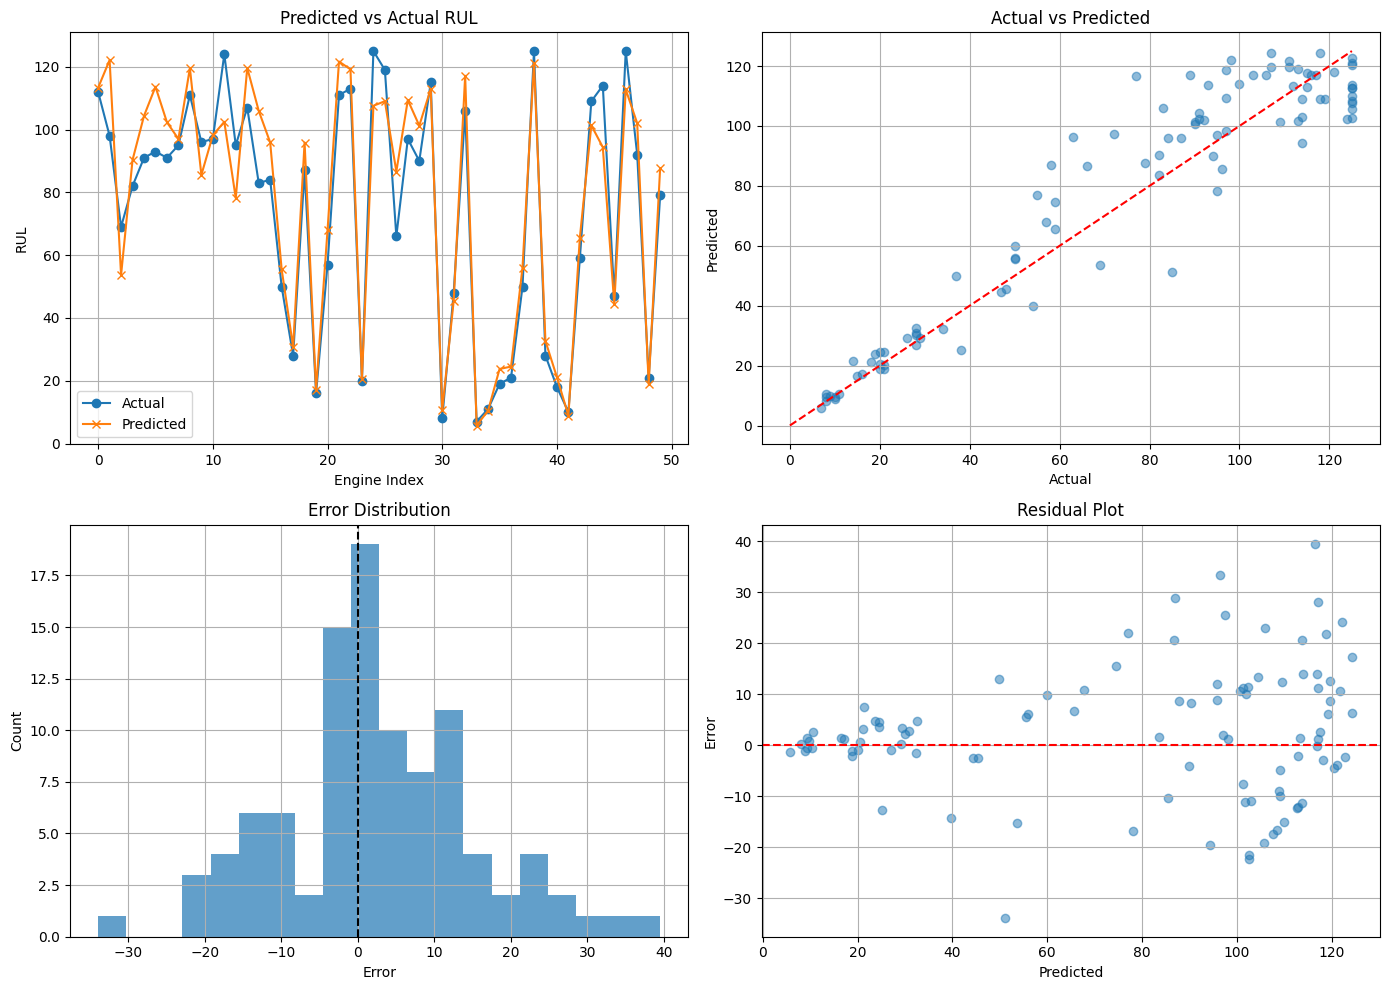


Graph saved as: final_results.png


In [50]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("\n===== FINAL RESULTS =====")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2  : {r2:.3f}")



#Graphs
plt.figure(figsize=(14,10))

# Predicted vs Actual
plt.subplot(2,2,1)
plt.plot(y_test[:50], label="Actual", marker='o')
plt.plot(preds[:50], label="Predicted", marker='x')
plt.title("Predicted vs Actual RUL")
plt.xlabel("Engine Index")
plt.ylabel("RUL")
plt.legend()
plt.grid()

# Scatter Plot
plt.subplot(2,2,2)
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([0, MAX_RUL], [0, MAX_RUL], 'r--')
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid()

# Error Distribution
errors = preds - y_test
plt.subplot(2,2,3)
plt.hist(errors, bins=20, alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.grid()

# Residual Plot
plt.subplot(2,2,4)
plt.scatter(preds, errors, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.grid()

plt.tight_layout()
plt.savefig("final_results.png", dpi=150)
plt.show()

print("\nGraph saved as: final_results.png")